In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [2]:
df = pd.read_csv('accounting_journal.csv')

In [3]:
summary = df.groupby('Account_Name')['Debit'].sum().reset_index()


In [4]:
#sort it from highest expense to lowest
summary = summary.sort_values(by='Debit',ascending=False)

print(summary)
print(f'                       {summary['Debit'].sum()}')

          Account_Name     Debit
2                 Cash  29021.07
4         Rent Expense  28665.44
3      Office Supplies  28144.64
1  Accounts Receivable  27029.33
5       Salary Expense  24168.24
0     Accounts Payable      0.00
6        Sales Revenue      0.00
                       137028.72


In [5]:
audit_report = df[df['Debit'] > 4000]
print(audit_report)

   Transaction_ID        Date  Account_ID         Account_Name Category  \
4         TXN-111  2026-04-03        5200      Office Supplies  Expense   
14        TXN-141  2026-04-04        5200      Office Supplies  Expense   
24        TXN-149  2026-04-07        1000                 Cash    Asset   
38        TXN-145  2026-04-10        1000                 Cash    Asset   
66        TXN-146  2026-04-21        5100       Salary Expense  Expense   
76        TXN-113  2026-04-25        1200  Accounts Receivable    Asset   
78        TXN-122  2026-04-25        5200      Office Supplies  Expense   
80        TXN-127  2026-04-25        1000                 Cash    Asset   
88        TXN-109  2026-04-28        5000         Rent Expense  Expense   
92        TXN-132  2026-04-28        5100       Salary Expense  Expense   
94        TXN-126  2026-04-29        1000                 Cash    Asset   
98        TXN-121  2026-04-30        5100       Salary Expense  Expense   

                  Descri

In [6]:
frequency_table = df['Account_Name'].value_counts()
print(frequency_table)

Account_Name
Cash                   31
Sales Revenue          20
Rent Expense           12
Accounts Receivable    10
Salary Expense          9
Office Supplies         9
Accounts Payable        9
Name: count, dtype: int64


In [7]:
frequecy_category = df['Category'].value_counts()
print(frequecy_category)

Category
Asset        41
Expense      30
Revenue      20
Liability     9
Name: count, dtype: int64


In [8]:
revenue_data = df[df['Category'] == 'Revenue']
total_revenue = revenue_data['Credit'].sum()

expense_data = df[df['Category'] == 'Expense']
total_expenses = expense_data['Debit'].sum()

net_income = total_revenue - total_expenses

print(f'Total Revenue: ${total_revenue}')
print(f'Total Expenses: ${total_expenses}')
print(f"Net Income: ${net_income}")

Total Revenue: $56050.399999999994
Total Expenses: $80978.32
Net Income: $-24927.920000000013


In [9]:
expense_data = df[df['Category'] == 'Expense']

sorted_expenses = expense_data.sort_values(by='Debit',ascending=False)

top_5_worst_expenses = sorted_expenses.head(5)

print(top_5_worst_expenses[['Date','Account_Name','Description','Debit']])

          Date     Account_Name                Description    Debit
88  2026-04-28     Rent Expense       Monthly rent payment  4870.09
78  2026-04-25  Office Supplies  Bought supplies on credit  4807.80
98  2026-04-30   Salary Expense     Employee salary payout  4636.96
14  2026-04-04  Office Supplies  Bought supplies on credit  4542.45
66  2026-04-21   Salary Expense     Employee salary payout  4363.73


In [10]:
trial_balance = df.groupby('Account_Name')[['Debit','Credit']].sum().reset_index()
print(trial_balance)

          Account_Name     Debit    Credit
0     Accounts Payable      0.00  28144.64
1  Accounts Receivable  27029.33      0.00
2                 Cash  29021.07  52833.68
3      Office Supplies  28144.64      0.00
4         Rent Expense  28665.44      0.00
5       Salary Expense  24168.24      0.00
6        Sales Revenue      0.00  56050.40


In [11]:
trial_balance['Net_Change'] = trial_balance['Debit'] - trial_balance['Credit']

print('---End of month Trial Balance ---')
print(trial_balance)

---End of month Trial Balance ---
          Account_Name     Debit    Credit  Net_Change
0     Accounts Payable      0.00  28144.64   -28144.64
1  Accounts Receivable  27029.33      0.00    27029.33
2                 Cash  29021.07  52833.68   -23812.61
3      Office Supplies  28144.64      0.00    28144.64
4         Rent Expense  28665.44      0.00    28665.44
5       Salary Expense  24168.24      0.00    24168.24
6        Sales Revenue      0.00  56050.40   -56050.40


In [12]:
Debit_by_category = df.groupby(['Category','Account_Name'])['Debit'].sum()
print(Debit_by_category)

Category   Account_Name       
Asset      Accounts Receivable    27029.33
           Cash                   29021.07
Expense    Office Supplies        28144.64
           Rent Expense           28665.44
           Salary Expense         24168.24
Liability  Accounts Payable           0.00
Revenue    Sales Revenue              0.00
Name: Debit, dtype: float64


In [13]:
Credit_by_category = df.groupby(['Category','Account_Name'])['Credit'].sum()
print(Credit_by_category)

Category   Account_Name       
Asset      Accounts Receivable        0.00
           Cash                   52833.68
Expense    Office Supplies            0.00
           Rent Expense               0.00
           Salary Expense             0.00
Liability  Accounts Payable       28144.64
Revenue    Sales Revenue          56050.40
Name: Credit, dtype: float64


<Axes: xlabel='Account_Name'>

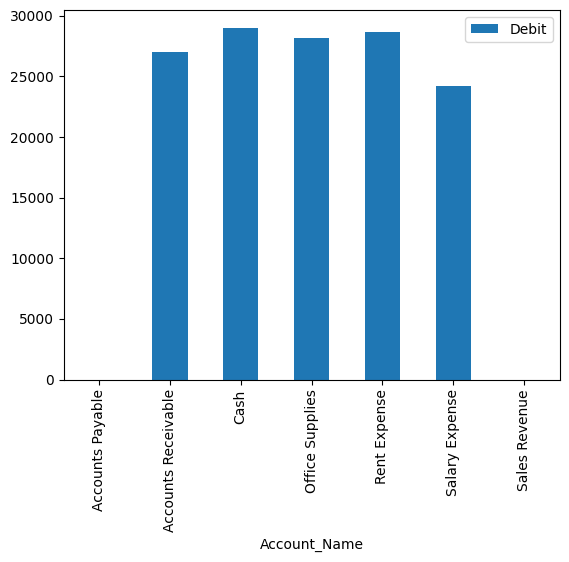

In [14]:
trial_balance.plot(kind='bar',x='Account_Name',y='Debit')

In [15]:
drill_down = df.groupby(['Category','Account_Name'])[['Debit','Credit']].sum()
print(drill_down)

                                  Debit    Credit
Category  Account_Name                           
Asset     Accounts Receivable  27029.33      0.00
          Cash                 29021.07  52833.68
Expense   Office Supplies      28144.64      0.00
          Rent Expense         28665.44      0.00
          Salary Expense       24168.24      0.00
Liability Accounts Payable         0.00  28144.64
Revenue   Sales Revenue            0.00  56050.40


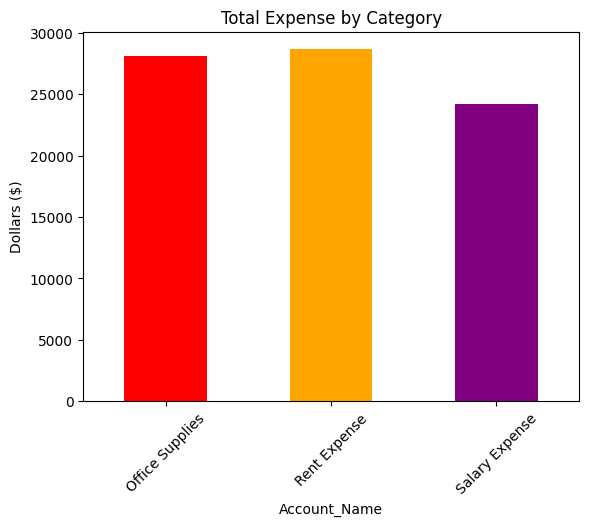

In [16]:
expense_data = df[df['Category'] == 'Expense']

expense_summary = expense_data.groupby('Account_Name')['Debit'].sum()


expense_summary.plot(kind='bar',title='Total Expense by Category',color=['red','orange','purple'])
plt.ylabel('Dollars ($)')
plt.xticks(rotation=45)

plt.show()

In [17]:
cash_data = df[df['Account_Name'] == 'Cash'].copy()
cash_data['Net_Cash'] = cash_data['Debit'] - cash_data['Credit']

daily_cash = cash_data.groupby('Date')['Net_Cash'].sum().reset_index()

daily_cash


,Date,Net_Cash
0,2026-04-02,-3436.95
1,2026-04-03,-2976.92
2,2026-04-05,-2828.32
3,2026-04-07,-2523.57
4,2026-04-09,-372.01
5,2026-04-10,3649.89
6,2026-04-12,119.17
7,2026-04-13,-431.05
8,2026-04-15,-209.42
9,2026-04-19,-4093.82


In [18]:
daily_cash['Bank_Account_Balance'] = daily_cash['Net_Cash'].cumsum()
print(daily_cash)

          Date  Net_Cash  Bank_Account_Balance
0   2026-04-02  -3436.95              -3436.95
1   2026-04-03  -2976.92              -6413.87
2   2026-04-05  -2828.32              -9242.19
3   2026-04-07  -2523.57             -11765.76
4   2026-04-09   -372.01             -12137.77
5   2026-04-10   3649.89              -8487.88
6   2026-04-12    119.17              -8368.71
7   2026-04-13   -431.05              -8799.76
8   2026-04-15   -209.42              -9009.18
9   2026-04-19  -4093.82             -13103.00
10  2026-04-21  -4363.73             -17466.73
11  2026-04-22   -244.26             -17710.99
12  2026-04-24  -3517.79             -21228.78
13  2026-04-25   4935.09             -16293.69
14  2026-04-26    654.34             -15639.35
15  2026-04-28  -6456.10             -22095.45
16  2026-04-29   4020.88             -18074.57
17  2026-04-30  -5738.04             -23812.61


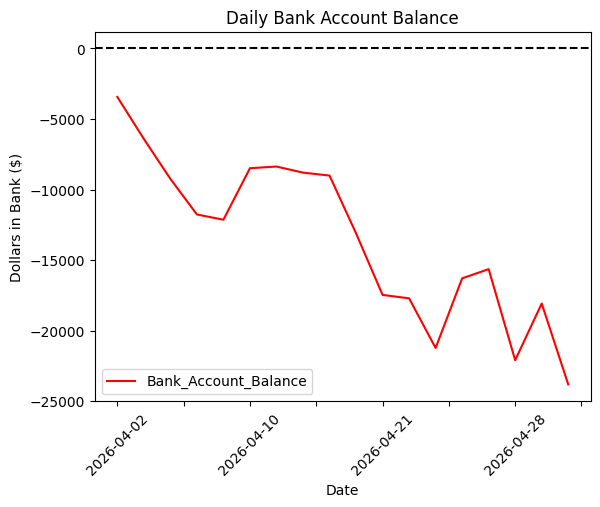

In [19]:
daily_cash.plot(kind='line',x='Date',y='Bank_Account_Balance',title='Daily Bank Account Balance',color='red')
plt.ylabel('Dollars in Bank ($)')
plt.xticks(rotation=45)
plt.axhline(0,color='black',linestyle='--')

plt.show()

In [20]:
assets_data = df[df['Category'] == 'Asset']
total_assets = assets_data['Debit'].sum() - assets_data['Credit'].sum()
total_assets

np.float64(3216.719999999994)

In [21]:
liabilities_data = df[df['Category'] == 'Liability']
total_liabilities = liabilities_data['Credit'].sum() - liabilities_data['Debit'].sum()
total_liabilities

np.float64(28144.640000000003)

In [22]:
revenue_data = df[df['Category'] == 'Revenue']
expense_data = df[df['Category'] == 'Expense']

net_income = (revenue_data['Credit'].sum() - revenue_data['Debit'].sum()) - (expense_data['Debit'].sum() - expense_data['Credit'].sum())

net_income

np.float64(-24927.920000000013)

In [23]:
print('--- The Balance Sheet ----')
print(f'Total Assets: ${total_assets:,.2f}')
print(f'Total Liabilities ${total_liabilities:,.2f}')
print(f'Total Equity: ${net_income:,.2f} (from net Income)')
print("--------------------------")

--- The Balance Sheet ----
Total Assets: $3,216.72
Total Liabilities $28,144.64
Total Equity: $-24,927.92 (from net Income)
--------------------------


In [24]:
right_side_of_equation = total_liabilities + net_income


print(f'Mathematical Proof: Does {total_assets:,.2f} == {right_side_of_equation:,.2f}?')
print("Is the Accounting Equation Balance",round(total_assets,2) == round(right_side_of_equation,2))

Mathematical Proof: Does 3,216.72 == 3,216.72?
Is the Accounting Equation Balance True


In [25]:
df_aging = pd.read_csv('ar_aging_data.csv')



In [ ]:
df_aging['Outstanding_Balance'] = df_aging['Invoice_Amount'] - df_aging['Amount_Paid']

df_aging['Due_Date'] = pd.to_datetime(df_aging['Due_Date'])

unpaid_invoices = df_aging[df_aging['Outstanding_Balance'] > 0]




today = pd.to_datetime('today')
df_aging['Days_Overdue'] = (today - df_aging['Due_Date']).dt.days

print(unpaid_invoices[['Customer_Name','Outstanding_Balance','Days_Overdue']])


KeyError: "['Days_Overdue'] not in index"